In [ ]:
import pandas as pd
data = pd.read_csv('bigmart.csv')
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


- Item_Identifier:
→ Code unique attribué à chaque produit vendu (par ex. "FDA15").
🔹 Sert à identifier les articles dans l’ensemble de données.

- Item_Weight
→ Poids de l’article (en kilogrammes).
🔹 Peut influencer les coûts de transport et de stockage.

- Item_Fat_Content
→ Teneur en matières grasses de l’article (par ex. "Low Fat", "Regular").
🔹 Catégorise les produits alimentaires selon leur composition.

- Item_Visibility
→ Pourcentage de la surface totale des rayons occupée par ce produit dans le magasin.
🔹 Représente la visibilité du produit pour les clients.

- Item_Type
→ Catégorie du produit (par ex. "Dairy", "Soft Drinks", "Meat", etc.).
🔹 Permet de regrouper les articles selon leur type.

- Item_MRP
→ Prix de vente maximum (Maximum Retail Price) de l’article.
🔹 C’est le prix de référence ou le prix conseillé du produit.

- Outlet_Identifier
→ Code unique identifiant chaque point de vente (par ex. "OUT049").
🔹 Permet de relier les ventes à un magasin spécifique.

- Outlet_Establishment_Year
→ Année d’ouverture du magasin.
🔹 Permet d’étudier l’ancienneté du point de vente.

- Outlet_Size
→ Taille du magasin (par ex. "Small", "Medium", "High").
🔹 Donne une idée de la capacité ou de la superficie du point de vente.

- Outlet_Location_Type
→ Type d’emplacement géographique du magasin (par ex. "Tier 1", "Tier 2", "Tier 3").
🔹 Indique si le magasin est situé dans une grande ville, une ville moyenne ou une zone rurale.

- Outlet_Type
→ Type de point de vente (par ex. "Supermarket Type1", "Grocery Store", etc.).
🔹 Décrit le format commercial du magasin.

- Item_Outlet_Sales
→ Montant total des ventes de cet article dans un magasin particulier (en unités monétaires).
🔹 C’est la variable cible dans la plupart des analyses de ce dataset (ce qu’on veut prédire).

In [ ]:
data.shape

(8523, 12)

In [ ]:
data.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [ ]:
# getting some information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
#checking for missing values
data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


** handling missing values **


In [13]:
# filling the missing values in "Item_weight column" with "Mean" value
data['Item_Weight'].fillna(data['Item_Weight'].mean(), inplace=True)

In [11]:
print(data['Outlet_Size'].mode())

0    Medium
Name: Outlet_Size, dtype: object


In [10]:
## filling the missing values in "Outlet_Size column" with the more repeated value
data['Outlet_Size'].fillna(data['Outlet_Size'].mode()[0], inplace=True)

/tmp/ipython-input-94093576.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Outlet_Size'].fillna(data['Outlet_Size'].mode()[0], inplace=True)


In [14]:
#checking for missing values
data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


**data visualization**

In [15]:
# generates descriptive statistics of  data
data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


1- **visualization** of   numerical values

<Axes: >

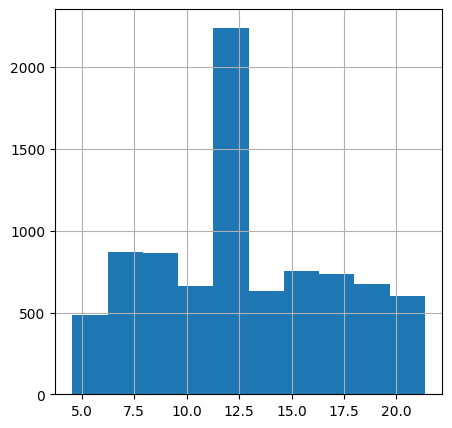

In [23]:
## Item_Weight distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
data['Item_Weight'].hist()

/tmp/ipython-input-3529495274.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Item_Weight'])


<Axes: xlabel='Item_Weight', ylabel='Density'>

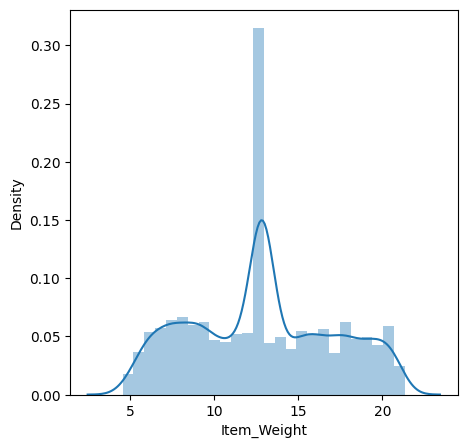

In [22]:
import seaborn as sns
plt.figure(figsize=(5,5))
sns.distplot(data['Item_Weight'])

/tmp/ipython-input-3150878556.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Item_Visibility'])


<Axes: xlabel='Item_Visibility', ylabel='Density'>

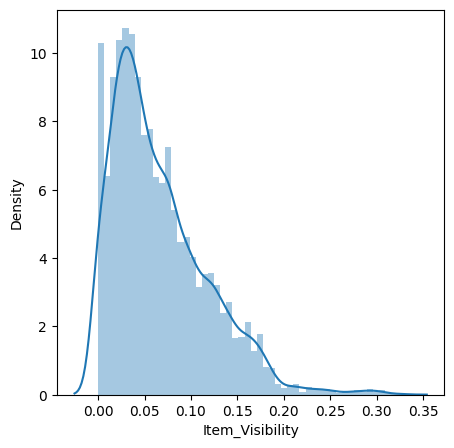

In [21]:
#item visisbility distribution
plt.figure(figsize=(5,5))
sns.distplot(data['Item_Visibility'])

/tmp/ipython-input-2164144081.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Item_MRP'])


<Axes: xlabel='Item_MRP', ylabel='Density'>

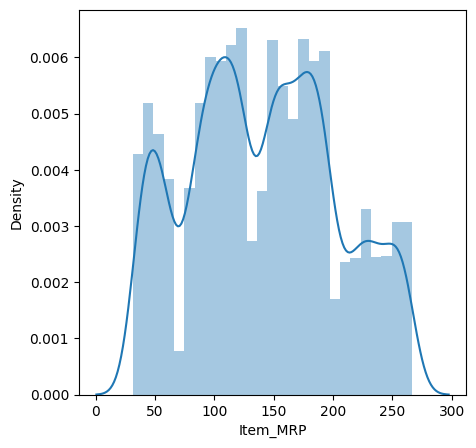

In [24]:
#item MRP distribution
plt.figure(figsize=(5,5))
sns.distplot(data['Item_MRP'])

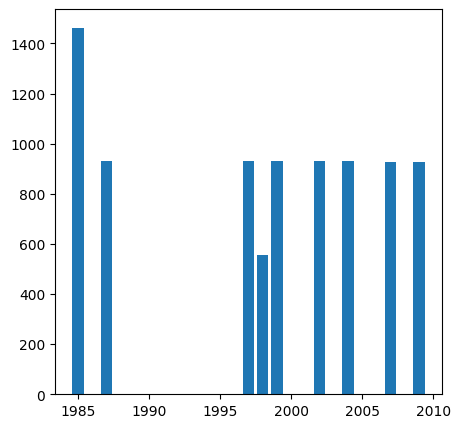

In [30]:
# Outlet_Establishment_Year distributon
plt.figure(figsize=(5,5))
Y=data['Outlet_Establishment_Year'].value_counts()
plt.bar(Y.index, Y.values)
plt.show()

2-**Visualization of categorical values **

<Axes: xlabel='Item_Fat_Content'>

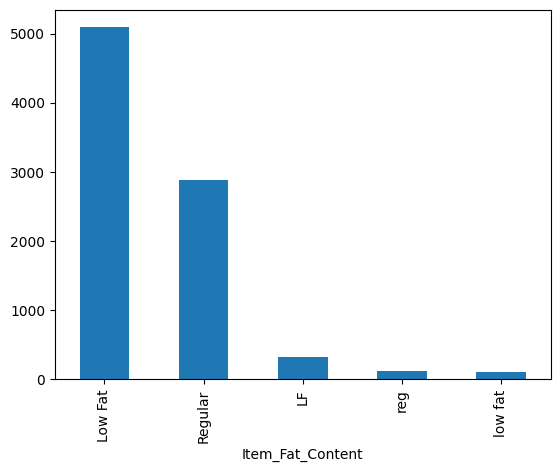

In [32]:
#item_fat coulunm
data['Item_Fat_Content'].value_counts().plot.bar()

<Axes: xlabel='Item_Type'>

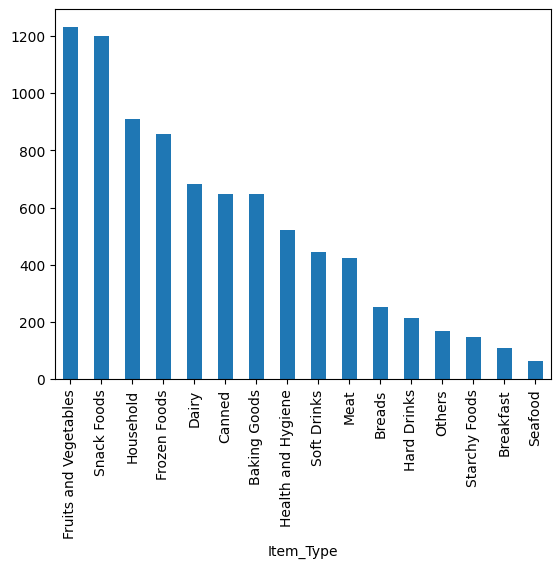

In [36]:
#item type values
data['Item_Type'].value_counts().plot.bar()

<Axes: xlabel='Outlet_Size'>

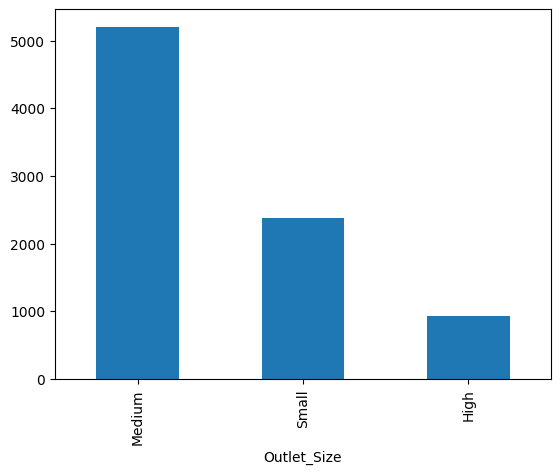

In [37]:
#Outlet_Size column
data['Outlet_Size'].value_counts().plot.bar()


<Axes: >

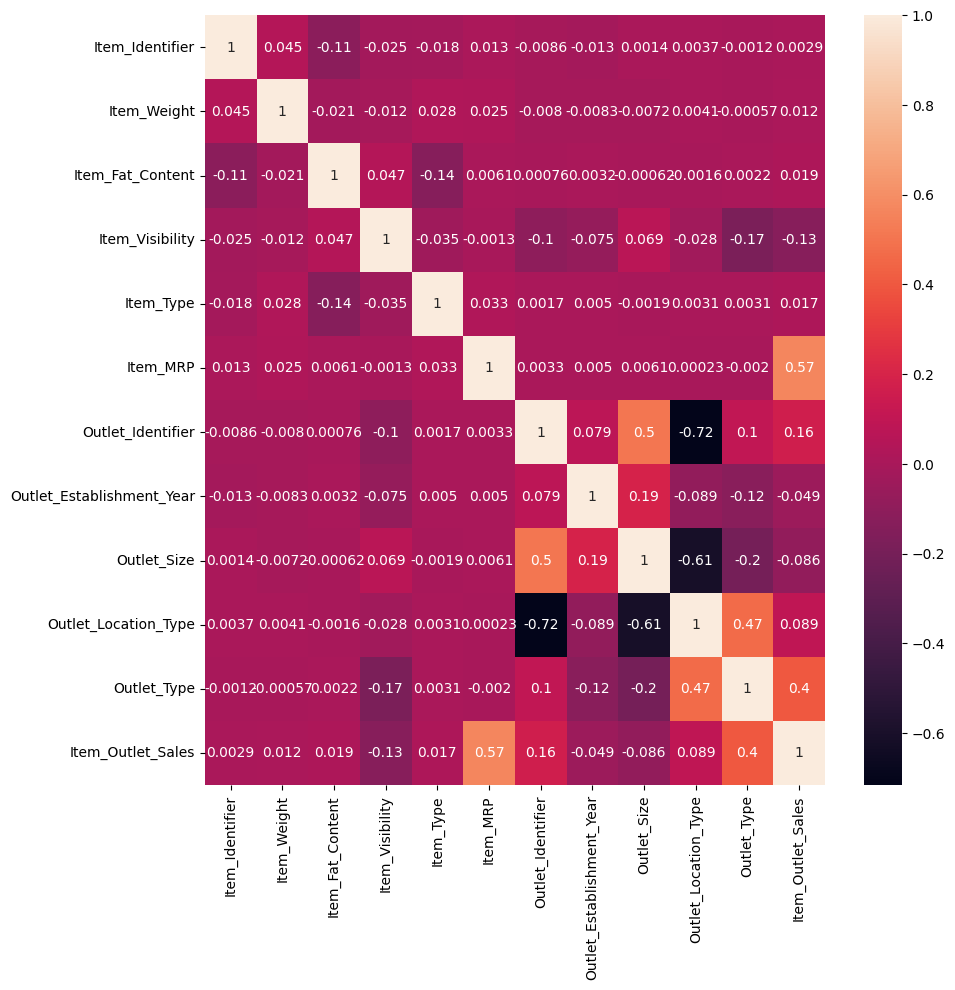

In [67]:
#show heatmap matrix
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(), annot=True)

**Data Pre-Processing**

In [39]:
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [38]:
# Item_Fat_Content values
print(data['Item_Fat_Content'].value_counts())

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


In [40]:
#mapping of values
data['Item_Fat_Content']=data['Item_Fat_Content'].replace({'LF':'Low Fat', 'reg':'Regular', 'low fat':'Low Fat'})
print(data['Item_Fat_Content'].value_counts())

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


In [43]:
data['Outlet_Type'].value_counts()

,count
Outlet_Type,
Supermarket Type1,5577
Grocery Store,1083
Supermarket Type3,935
Supermarket Type2,928


- encoding of categorical values

In [50]:
#encoding of categorical values
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['Item_Fat_Content']=le.fit_transform(data['Item_Fat_Content'])
data['Item_Type']=le.fit_transform(data['Item_Type'])
data['Outlet_Size']=le.fit_transform(data['Outlet_Size'])
data['Outlet_Location_Type']=le.fit_transform(data['Outlet_Location_Type'])
data['Outlet_Type']=le.fit_transform(data['Outlet_Type'])
data['Outlet_Identifier']=le.fit_transform(data['Outlet_Identifier'])
data['Item_Identifier']=le.fit_transform(data['Item_Identifier'])

In [55]:
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,156,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,8,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,662,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,1121,19.20,1,0.000000,6,182.0950,0,1998,1,2,0,732.3800
4,1297,8.93,0,0.000000,9,53.8614,1,1987,0,2,1,994.7052


**prepare data for model training **

In [56]:
#separate features and traget
X=data.drop(columns='Item_Outlet_Sales', axis=1)
Y=data['Item_Outlet_Sales']

In [60]:
#features
X.head(2)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,156,9.30,0,0.016047,4,249.8092,9,1999,1,0,1
1,8,5.92,1,0.019278,14,48.2692,3,2009,1,2,2


In [59]:
#target
Y.head(2)

,Item_Outlet_Sales
0,3735.1380
1,443.4228


In [61]:
#splitting data into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, random_state=2)


**Train a linear regression model**

In [62]:
#train a LinearRegression model
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train, Y_train)

LinearRegression()

In [63]:
#test the model
Y_pred=lr.predict(X_test)
#compare Y_pred and Y_test
from sklearn.metrics import r2_score
r2_score(Y_test, Y_pred)

0.49498230467979

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 938.3298876055019
RMSE: 1248.6101695726866
R²: 0.49498230467979


**Decision tree**

In [75]:
#train a DecisionTreeRegressor model
from sklearn.tree import DecisionTreeRegressor
#define the model
dt=DecisionTreeRegressor()
#train the model
dt.fit(X_train, Y_train)

DecisionTreeRegressor()

In [77]:
#test model and evaluate it
Y_pred=dt.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1117.0335516715543
RMSE: 1594.198270959062
R²: 0.1767390278850569


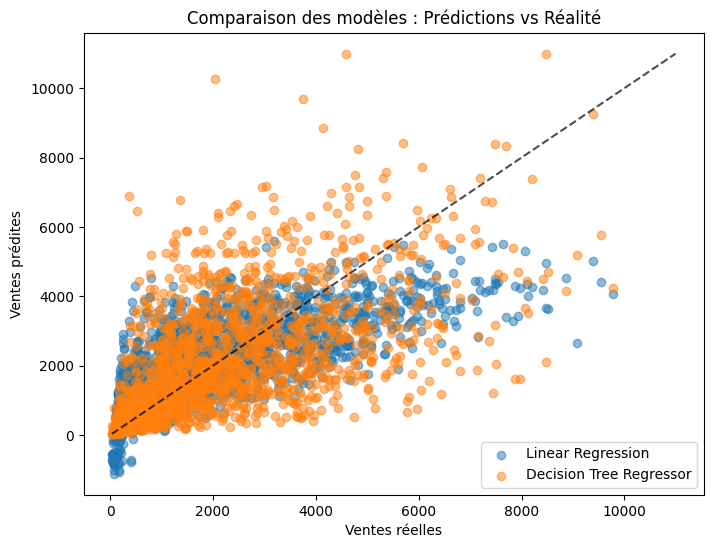

Comparaison des modèles :
                     Model          MAE         RMSE        R2
0        Linear Regression   938.329888  1248.610170  0.494982
1  Decision Tree Regressor  1107.352312  1588.133679  0.182991


In [78]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Définir les modèles
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor()
}

results = []

# Créer une figure unique
plt.figure(figsize=(8,6))

# Boucle sur les modèles
for name, model in models.items():
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)

    # Calcul des métriques
    mae = mean_absolute_error(Y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
    r2 = r2_score(Y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    # Scatter plot sur la même figure
    plt.scatter(Y_test, y_pred, alpha=0.5, label=name)

# Ligne y=x pour référence
lims = [min(Y_test.min(), np.min(y_pred)), max(Y_test.max(), np.max(y_pred))]
plt.plot(lims, lims, 'k--', alpha=0.7)  # ligne idéale
plt.xlabel("Ventes réelles")
plt.ylabel("Ventes prédites")
plt.title("Comparaison des modèles : Prédictions vs Réalité")
plt.legend()
plt.show()

# Comparaison des métriques
results_df = pd.DataFrame(results)
print("Comparaison des modèles :")
print(results_df.sort_values(by="R2", ascending=False))


**Train a randomforest model**

In [65]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
rf.fit(X_train, Y_train)

RandomForestRegressor()

In [66]:
#test model and evaluate it
Y_pred=rf.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 824.2853723812318
RMSE: 1175.4221529344313
R²: 0.5524509876857147
